## Customer Satisfaction Prediction - Project 4

### Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score
import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

### Loading Dataset

In [2]:
df = pd.read_csv("customer_support_tickets (1).csv")

In [3]:
df.head() 

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


#### Read and explore the data

In [4]:
df.shape

(8469, 17)

In [5]:
df.isnull().sum()

Ticket ID                          0
Customer Name                      0
Customer Email                     0
Customer Age                       0
Customer Gender                    0
Product Purchased                  0
Date of Purchase                   0
Ticket Type                        0
Ticket Subject                     0
Ticket Description                 0
Ticket Status                      0
Resolution                      5700
Ticket Priority                    0
Ticket Channel                     0
First Response Time             2819
Time to Resolution              5700
Customer Satisfaction Rating    5700
dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   object 
 2   Customer Email                8469 non-null   object 
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   object 
 5   Product Purchased             8469 non-null   object 
 6   Date of Purchase              8469 non-null   object 
 7   Ticket Type                   8469 non-null   object 
 8   Ticket Subject                8469 non-null   object 
 9   Ticket Description            8469 non-null   object 
 10  Ticket Status                 8469 non-null   object 
 11  Resolution                    2769 non-null   object 
 12  Ticket Priority               8469 non-null   object 
 13  Tic

In [7]:
df.describe()

,Ticket ID,Customer Age,Customer Satisfaction Rating
count,8469.000000,8469.000000,2769.000000
mean,4235.000000,44.026804,2.991333
std,2444.934048,15.296112,1.407016
min,1.000000,18.000000,1.000000
25%,2118.000000,31.000000,2.000000
50%,4235.000000,44.000000,3.000000
75%,6352.000000,57.000000,4.000000
max,8469.000000,70.000000,5.000000


In [8]:
df.duplicated().sum()

np.int64(0)

### Handling Missing Values

In [9]:
df["Customer Satisfaction Rating"] = df["Customer Satisfaction Rating"].fillna(df["Customer Satisfaction Rating"].median())

In [10]:
def rating(num):
    if 0<= num >= 3:
        return "low"
    elif 3 < num >= 5:
        return "Medium"
    else:
        return "High"
df["Customer Satisfaction Rating"] = df["Customer Satisfaction Rating"].apply(rating)

In [11]:
df['Resolution'] = df['Resolution'].fillna(df['Resolution'].mode()[0])

In [12]:
df.head(2)

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,A former wrong interview then heart leg.,Critical,Social media,2023-06-01 12:15:36,NaN,low
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,A former wrong interview then heart leg.,Critical,Chat,2023-06-01 16:45:38,NaN,low


In [13]:
df.isnull().sum()

Ticket ID                          0
Customer Name                      0
Customer Email                     0
Customer Age                       0
Customer Gender                    0
Product Purchased                  0
Date of Purchase                   0
Ticket Type                        0
Ticket Subject                     0
Ticket Description                 0
Ticket Status                      0
Resolution                         0
Ticket Priority                    0
Ticket Channel                     0
First Response Time             2819
Time to Resolution              5700
Customer Satisfaction Rating       0
dtype: int64

### Feature Engineering

In [14]:
df['First Response Time'] = pd.to_datetime(df['First Response Time'])
df['Time to Resolution'] = pd.to_datetime(df['Time to Resolution'])
df['Date of Purchase'] = pd.to_datetime(df['Date of Purchase']) 

In [15]:
df['First_Response_month'] = df['First Response Time'].dt.month

In [16]:
df['Resolution_month'] = df['Time to Resolution'].dt.month

In [17]:
df['purchase_year'] = df['Date of Purchase'].dt.year
df['purchase_month'] = df['Date of Purchase'].dt.month

In [18]:
df['First_Response_month'] = df['First_Response_month'].fillna(df['First_Response_month'].median())
df['Resolution_month'] = df['Resolution_month'].fillna(df['Resolution_month'].median())

In [19]:
df = df.drop(columns=[
    'First Response Time',
    'Time to Resolution',
    'Date of Purchase'
])

In [20]:
df.isnull().sum()

Ticket ID                       0
Customer Name                   0
Customer Email                  0
Customer Age                    0
Customer Gender                 0
Product Purchased               0
Ticket Type                     0
Ticket Subject                  0
Ticket Description              0
Ticket Status                   0
Resolution                      0
Ticket Priority                 0
Ticket Channel                  0
Customer Satisfaction Rating    0
First_Response_month            0
Resolution_month                0
purchase_year                   0
purchase_month                  0
dtype: int64

In [21]:
df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,Customer Satisfaction Rating,First_Response_month,Resolution_month,purchase_year,purchase_month
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,A former wrong interview then heart leg.,Critical,Social media,low,6.0,6.0,2021,3
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,A former wrong interview then heart leg.,Critical,Chat,low,6.0,6.0,2021,5
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,low,6.0,6.0,2020,7
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,low,6.0,6.0,2020,11
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,High,6.0,6.0,2020,2


In [22]:
def clean_text(text):
    text = str(text).lower()                         # lowercase
    text = re.sub(r'http\S+', '', text)              # remove URLs
    text = re.sub(r'[^a-zA-Z\s]', '', text)          # remove punctuation/numbers
    text = re.sub(r'\s+', ' ', text).strip()         # remove extra spaces
    return text

df['clean_description'] = df['Ticket Description'].apply(clean_text)

In [23]:
df['tokens'] = df['clean_description'].apply(word_tokenize)

In [24]:
stop_words = set(stopwords.words('english'))

df['tokens'] = df['tokens'].apply(
    lambda x: [word for word in x if word not in stop_words]
)

In [25]:
lemmatizer = WordNetLemmatizer()

custom_words = ["im", "please", "assist"]
df['tokens'] = df['tokens'].apply(
    lambda x: [word for word in x if word not in custom_words]
)

In [26]:
df['processed_text'] = df['tokens'].apply(lambda x: " ".join(x))

#### Data Visualization 

#### 1. Customer Satisfaction Distribution

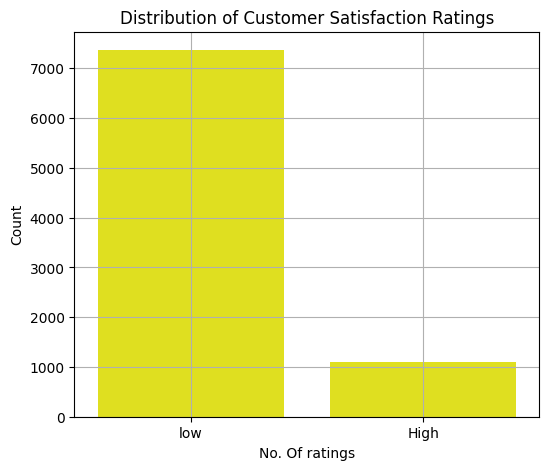

In [27]:
plt.figure(figsize = (6,5))
sns.countplot(x = 'Customer Satisfaction Rating', data = df, color = "yellow")
plt.title("Distribution of Customer Satisfaction Ratings")
plt.xlabel("No. Of ratings")
plt.ylabel("Count")
plt.grid()
plt.show()

Observation:

Most customer satisfaction ratings are concentrated at the higher end, indicating generally positive feedback, with fewer low ratings.

Model may become biased toward predicting middle values

#### 2. Ticket Type Distribution

C:\Users\User\AppData\Local\Temp\ipykernel_6704\3333403186.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Ticket Type', data=df, order=df['Ticket Type'].value_counts().index, palette='viridis')


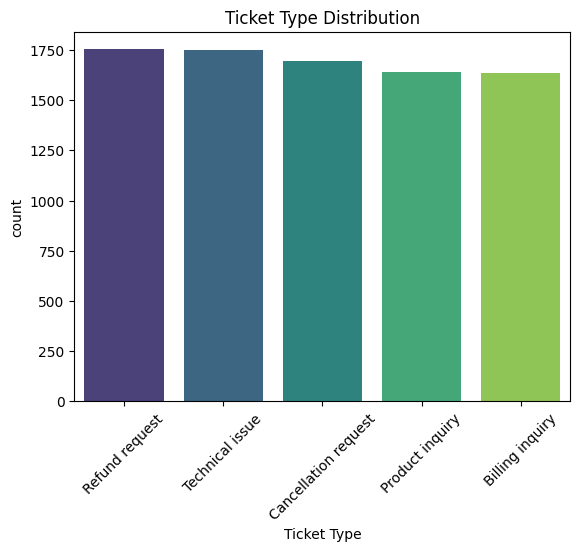

In [29]:
sns.countplot(x='Ticket Type', data=df, order=df['Ticket Type'].value_counts().index, palette='viridis')
plt.title("Ticket Type Distribution")
plt.xticks(rotation=45)
plt.show()

Observation:

Number of tickets for each type (e.g., Technical, Billing, General Inquiry, etc.)

Helps identify which issues are most common

#### 3. Ticket Status Distribution 

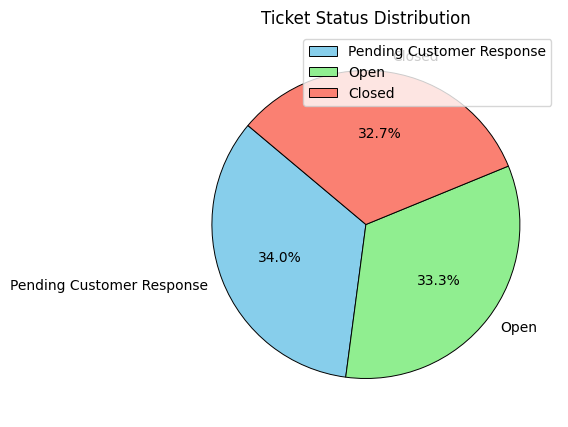

In [30]:
status_counts = df['Ticket Status'].value_counts()
plt.figure(figsize=(6,5))
plt.pie(
    status_counts,
    labels=status_counts.index,
    autopct='%1.1f%%',wedgeprops={ 'edgecolor': 'black',  'linewidth': 0.7 },  
    startangle=140,
    colors=['skyblue', 'lightgreen', 'salmon', 'gold']
)
plt.title("Ticket Status Distribution")
plt.legend()
plt.show()

Observation:

The largest portion of the pie chart corresponds to Resolved tickets, indicating that most customer issues are being handled successfully.

#### 4. Customer Gender Distribution

In [31]:
gender = df['Customer Gender'].value_counts()

C:\Users\User\AppData\Local\Temp\ipykernel_6704\2556649762.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gender.index, y=gender.values, palette='coolwarm')


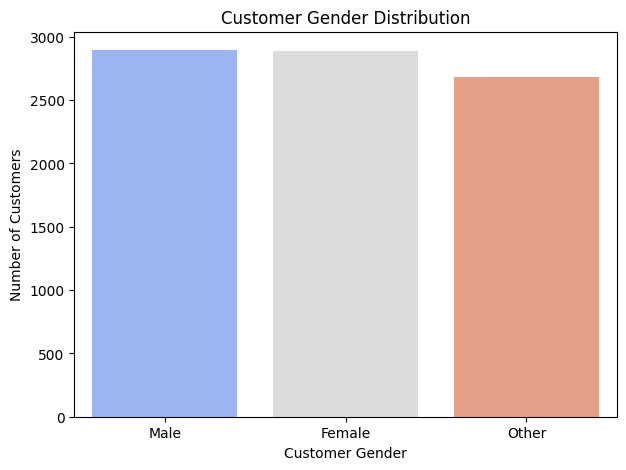

In [32]:
plt.figure(figsize=(7,5))
sns.barplot(x=gender.index, y=gender.values, palette='coolwarm')
plt.title("Customer Gender Distribution")
plt.ylabel("Number of Customers")
plt.show()

Observation:
The chart shows that the majority of customers identify as Female, followed by Male, while the Other category forms a small fraction of the customer base.

#### 5. Product Purchased by Year And Month

In [33]:
purchase_trend = df.groupby(['purchase_year', 'purchase_month']).size().reset_index(name='count')

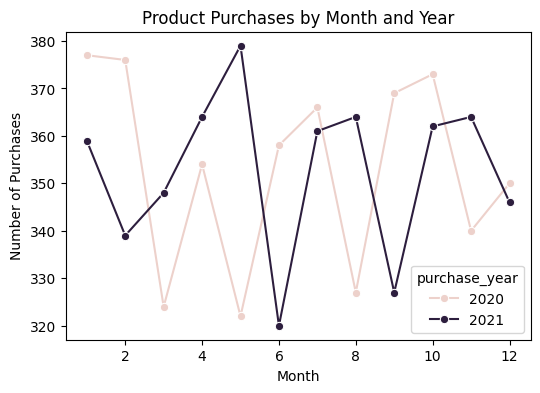

In [34]:
plt.figure(figsize=(6,4))
sns.lineplot(data=purchase_trend,
             x='purchase_month',
             y='count',
             hue='purchase_year',
             marker='o')

plt.title('Product Purchases by Month and Year')
plt.xlabel('Month')
plt.ylabel('Number of Purchases')
plt.show()

Observation:
The lines for different years show variation in purchase counts, suggesting that some years perform better than others overall.

#### Encoding the data

In [35]:
df =df.drop(columns = ["clean_description", "tokens", "Ticket ID", "Customer Name", "Customer Email","Ticket Description"])

In [43]:
from sklearn.preprocessing import LabelEncoder

cat_cols = ['Customer Gender', 'Product Purchased', 'Ticket Type',
            'Ticket Status', 'Ticket Priority', 'Ticket Channel', 'processed_text']

for col in cat_cols:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

#### Training & Evaluating the data

In [44]:
x = df.drop(columns = ["Customer Satisfaction Rating", "Ticket Subject", "Resolution"])
y= df["Customer Satisfaction Rating"]

In [45]:
x_train, x_test, y_train, y_test = train_test_split(x, y , test_size = 0.2, random_state = 42)

In [46]:
model = RandomForestClassifier(n_estimators = 300, random_state =42)
model.fit(x_train, y_train)

,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [47]:
y_pred = model.predict(x_test)

In [48]:
print(round(accuracy_score(y_test, y_pred),2))

0.86


In [52]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

        High       0.38      0.11      0.17       224
         low       0.88      0.97      0.92      1470

    accuracy                           0.86      1694
   macro avg       0.63      0.54      0.55      1694
weighted avg       0.81      0.86      0.82      1694

[[  24  200]
 [  39 1431]]


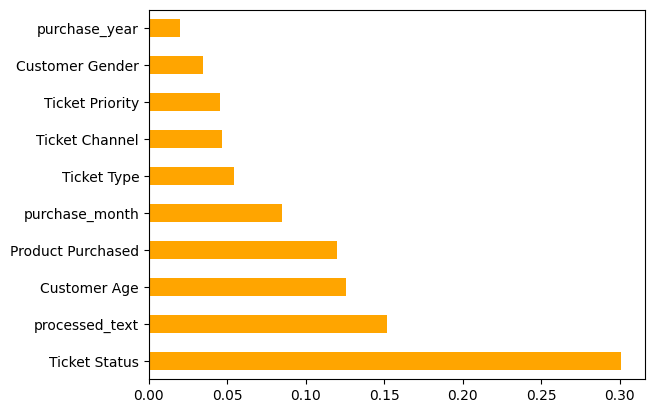

In [53]:
feat_importances = pd.Series(model.feature_importances_, index=x_train.columns)
feat_importances.nlargest(10).plot(kind='barh', color = "orange")
plt.show()